5. Implement the Quantum Fourier Transform (QFT) and its inverse using Qiskit

In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=edb3b3efb1ca09774d5de9072b6d1de219a1e11e2d477c08d9338504e11f0241
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Result: {'101': 1024}


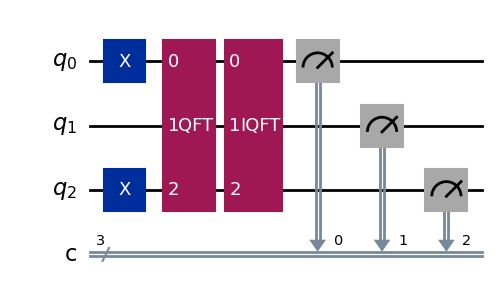

In [2]:
# 5. Implement the Quantum Fourier Transform (QFT) and its inverse using Qiskit

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def build_qft(n):
    qc = QuantumCircuit(n, name="QFT")

    for j in reversed(range(n)):
        qc.h(j)
        for m in range(j):
            qc.cp(np.pi / (2 ** (j - m)), m, j)

    # Swap qubits (bit reversal)
    for i in range(n // 2):
        qc.swap(i, n - i - 1)

    return qc

# Number of qubits
n = 3

# Build QFT and inverse
qft = build_qft(n)
iqft = qft.inverse()
iqft.name = "IQFT"

# Create test circuit
qc = QuantumCircuit(n, n)

# 🔹 Prepare a test state |101>
qc.x(0)
qc.x(2)

# Apply QFT then inverse QFT
qc.append(qft, range(n))
qc.append(iqft, range(n))

# Measure
qc.measure(range(n), range(n))

# Simulate
backend = AerSimulator()
result = backend.run(transpile(qc, backend), shots=1024).result()

counts = result.get_counts()

print("Result:", counts)
qc.draw('mpl')